<a href="https://colab.research.google.com/github/ainfitribasri/KELOMPOK-6/blob/main/Copy_of_Hands_On_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [52]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1051)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 25.5
beta0 = 61
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


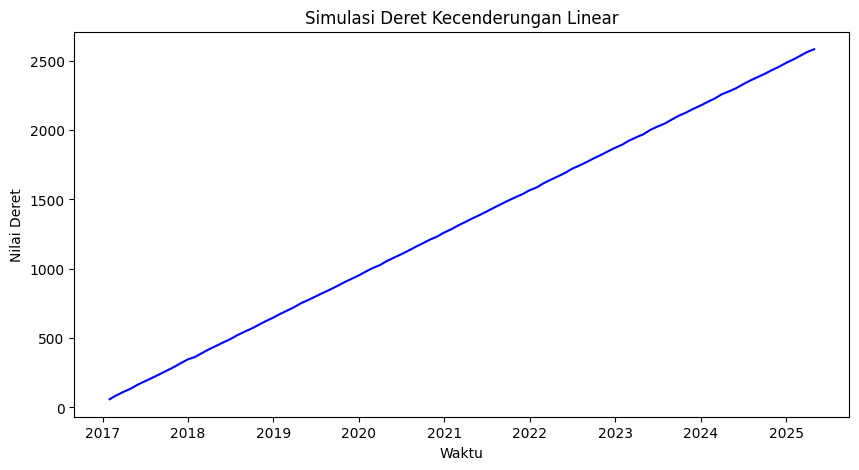

In [53]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?


JAWAB

Berdasarkan hasil perhitungan, nilai korelasi antara Time dan Value adalah 1,0000. Nilai korelasi tersebut menunjukkan adanya hubungan linear positif yang sangat kuat antara waktu dan nilai deret. Artinya, seiring bertambahnya waktu, nilai deret juga cenderung meningkat.

In [54]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [55]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.719e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          8.87e-259
Time:                        15:00:34   Log-Likelihood:                -198.30
No. Observations:                 100   AIC:                             400.6
Df Residuals:                      98   BIC:                             405.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           60.7598      0.352    172.375   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

JAWAB

Hasil pengepasan model regresi linear menunjukkan bahwa parameter hasil estimasi sangat dekat dengan parameter asli. Nilai intercept hasil estimasi adalah 60,7598, sedangkan nilai parameter asli adalah 61. Sementara itu, koefisien Time_Numeric hasil estimasi adalah 25,5034, yang sangat dekat dengan parameter asli sebesar 25,5.

Model regresi dapat dikatakan sangat baik karena memiliki nilai R-squared sebesar 1,000, sehingga hampir seluruh variasi Value dapat dijelaskan oleh variabel waktu. Selain itu, nilai p-value untuk koefisien intercept dan Time_Numeric adalah 0,000, sehingga keduanya signifikan secara statistik. Dengan demikian, model regresi linear berhasil menangkap kecenderungan linear pada deret dengan sangat baik.


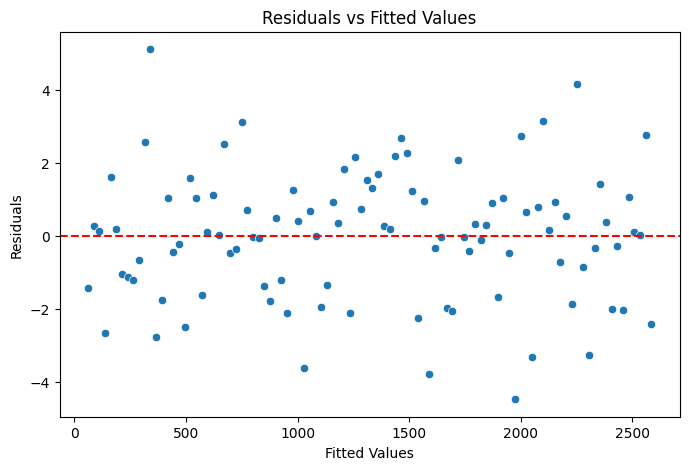

In [101]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

JAWAB

Berdasarkan plot Residuals vs Fitted Values, residual terlihat menyebar secara acak di sekitar garis nol dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa tidak terdapat pola sistematis pada residual, sehingga asumsi linearitas model dapat dikatakan terpenuhi. Penyebaran residual juga relatif merata sehingga tidak menunjukkan adanya masalah heteroskedastisitas yang jelas.

In [107]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.6196


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

JAWAB

Hasil uji Breusch-Pagan menunjukkan nilai p-value sebesar 0,6196. Karena nilai p-value lebih besar dari 0,05, maka tidak terdapat bukti yang cukup untuk menyatakan adanya heteroskedastisitas. Dengan demikian, asumsi homoskedastisitas pada model dapat dianggap terpenuhi.

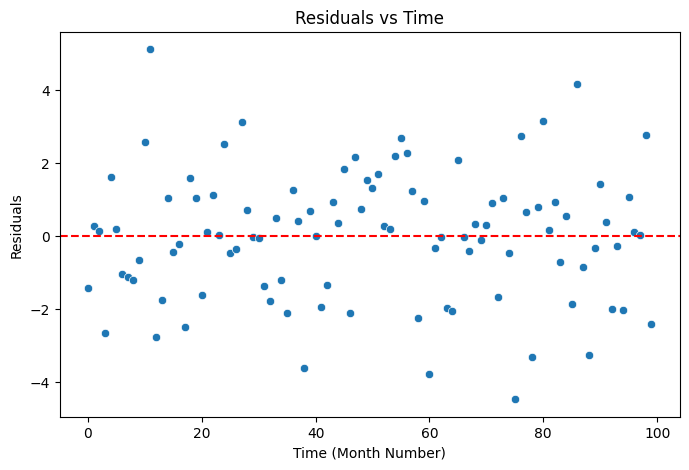

In [109]:
# Plot residual vs time
plt.figure(figsize=(8,5))

sns.scatterplot(x=model.model.exog[:, 1], y=model.resid)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

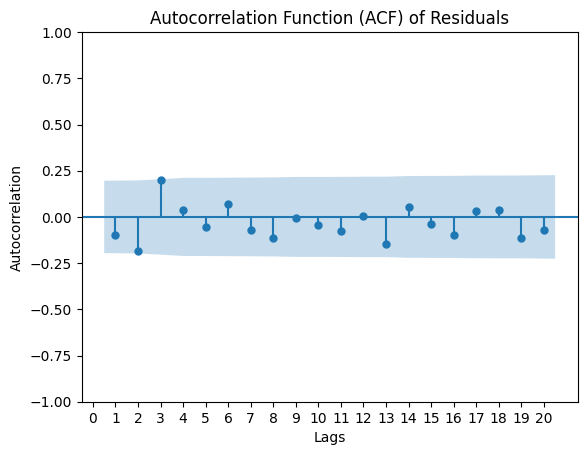

In [110]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


:Apa yang dapat Anda simpulkan dari plot di atas?

JAWAB

Berdasarkan kedua plot tersebut, residual terlihat menyebar secara acak di sekitar garis nol dan tidak menunjukkan pola tertentu terhadap waktu. Pada plot ACF, sebagian besar nilai autokorelasi residual berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa residual tidak memiliki pola sistematis maupun autokorelasi yang kuat. Dengan demikian, residual dari model dapat dianggap cukup baik dan tidak menunjukkan adanya ketergantungan waktu yang signifikan.

In [111]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.943464   0.331389
2    4.383047   0.111746
3    8.522943   0.036354
4    8.668225   0.069949
5    9.019080   0.108306
6    9.524726   0.146147
7   10.035191   0.186588
8   11.544371   0.172720
9   11.545882   0.240137
10  11.776819   0.300271
11  12.445584   0.331098
12  12.450265   0.410229
13  14.893786   0.314030
14  15.222700   0.363103
15  15.379531   0.424440
16  16.563931   0.414342
17  16.673193   0.476711
18  16.845268   0.533767
19  18.429513   0.493940


:Apa kesimpulan dari hasil uji Ljung-Box tersebut?

JAWAB

Berdasarkan hasil uji Ljung-Box, sebagian besar nilai p-value lebih besar dari 0,05, sehingga secara umum tidak terdapat bukti autokorelasi residual yang signifikan. Namun, pada lag ke-3 diperoleh p-value sebesar 0,0364 yang lebih kecil dari 0,05, sehingga terdapat indikasi autokorelasi pada lag tersebut. Secara keseluruhan, autokorelasi residual tidak terlihat kuat pada sebagian besar lag.

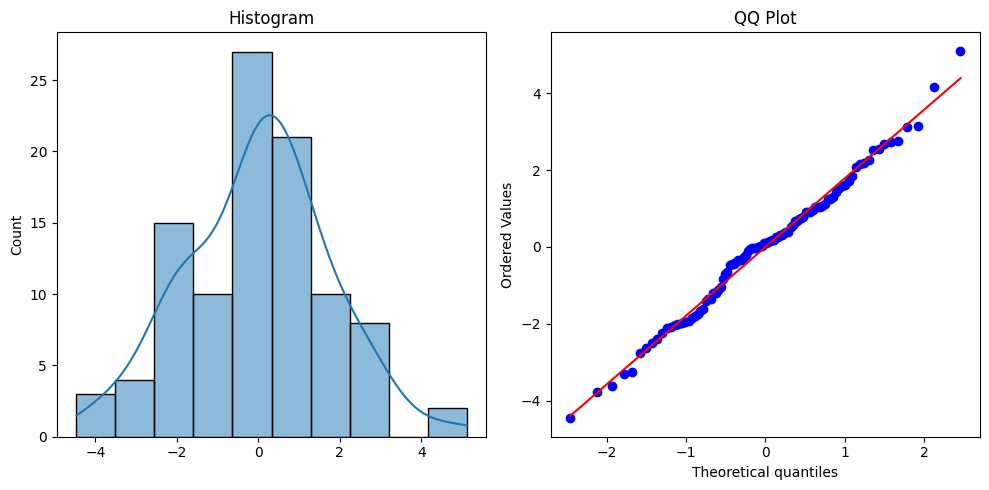

In [112]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

JAWAB

Berdasarkan histogram, residual secara umum memiliki distribusi yang mendekati normal dan berpusat di sekitar nol. Hal ini juga didukung oleh QQ Plot, di mana sebagian besar titik mengikuti garis diagonal. Meskipun terdapat sedikit penyimpangan pada bagian ekor, secara keseluruhan residual dapat dikatakan mendekati distribusi normal.

In [113]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9921720579108307, p-value = 0.8335472162709665


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

JAWAB

Uji Shapiro-Wilk menghasilkan p-value sebesar 0,8335 yang lebih besar dari 0,05, sehingga residual dapat dianggap berdistribusi normal. Hal ini sesuai dengan histogram dan QQ Plot yang menunjukkan bahwa residual secara umum mendekati distribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [114]:
# Menentukan parameter simulasi
np.random.seed(1051)
n_periods = 120
beta_0, beta_1, beta_2= 101, 25.5, 1.02
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

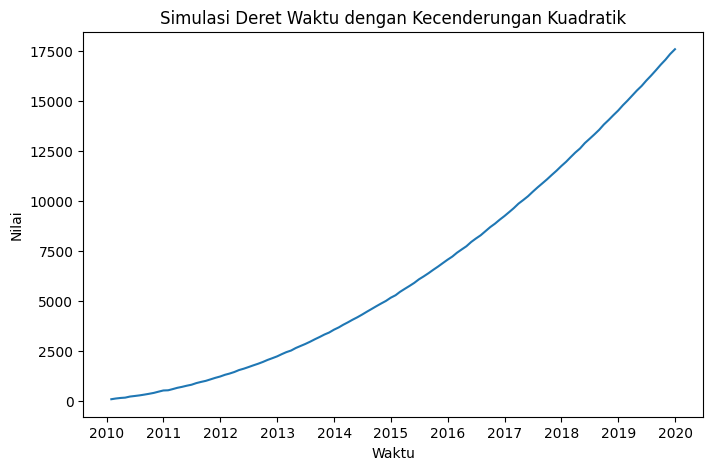

In [115]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

JAWAB

Deret menunjukkan kecenderungan meningkat dengan pola yang melengkung ke atas. Nilai deret semakin besar seiring bertambahnya waktu, dan laju peningkatannya juga semakin cepat. Berbeda dengan pola kecenderungan linear yang memiliki pola kenaikan relatif konstan dan membentuk garis lurus, pada pola kuadratik kenaikan deret semakin tajam sehingga membentuk kurva. Dengan demikian, deret pada plot di atas menunjukkan kecenderungan kuadratik.

In [116]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.792e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.15e-321
Time:                        16:28:37   Log-Likelihood:                -439.22
No. Observations:                 120   AIC:                             884.4
Df Residuals:                     117   BIC:                             892.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         98.6294      2.566     38.444      0.0

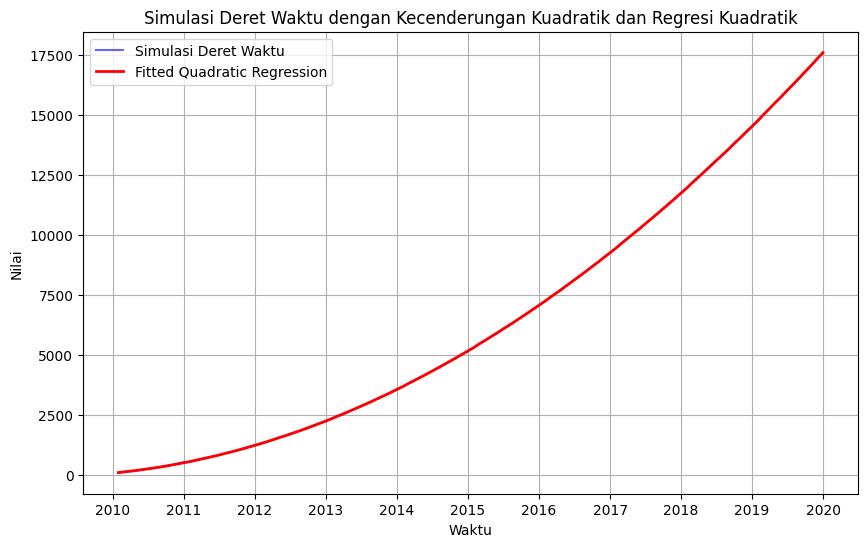

In [117]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

JAWAB

Model regresi kuadratik yang dipaskan sudah tepat untuk menggambarkan deret. Hal ini terlihat dari nilai R-squared sebesar 1,000 yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi pada data. Nilai parameter hasil estimasi juga sangat dekat dengan parameter asli, yaitu intercept sebesar 98,6294 dibandingkan β₀ = 101, koefisien x1 sebesar 25,5745 dibandingkan β₁ = 25,5, dan koefisien x2 sebesar 1,0196 dibandingkan β₂ = 1,02. Dengan demikian, model regresi kuadratik sudah sesuai dengan pola kecenderungan deret yang berbentuk melengkung dan meningkat.

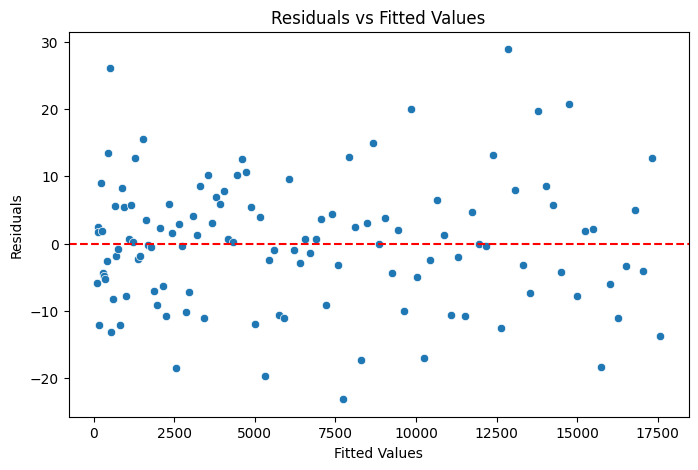

In [118]:
# cek asumsi model regresi kuadratik

# Plot Residuals vs Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model_quad.fittedvalues, y=model_quad.resid)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [120]:
# Menentukan parameter simulasi
np.random.seed(100)
n_periods = 120
beta0, beta1, beta2=101, -1275, -102
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


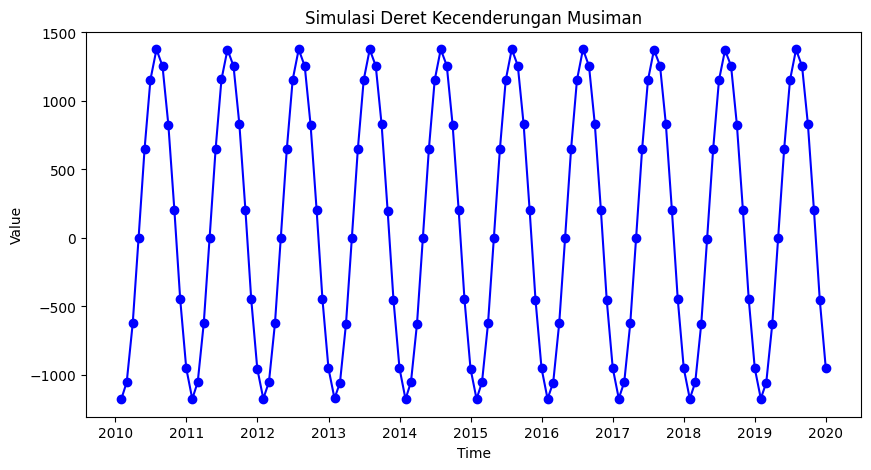

In [121]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

JAWAB

Deret menunjukkan pola musiman yang berulang secara teratur setiap 12 periode (12 bulan). Nilai deret mengalami kenaikan dan penurunan secara periodik dengan pola yang relatif sama dari tahun ke tahun. Hal ini menunjukkan adanya kecenderungan musiman dengan periode 12, sehingga pola pada suatu tahun akan kembali muncul pada tahun berikutnya.

In [122]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [123]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [126]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [125]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.332e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.75e-285
Time:                        16:37:22   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1174.5532      0.619  -1898.968      0.0

Bagaimana interpretasi dari hasil tersebut?

Hasil regresi musiman menunjukkan bahwa setiap koefisien bulan menggambarkan nilai rata-rata deret untuk bulan tersebut. Nilai koefisien berbeda-beda antarbulan, yang menunjukkan adanya pola musiman yang kuat. Nilai tertinggi terdapat pada bulan Juli sebesar 1375,2541, sedangkan nilai terendah terdapat pada bulan Januari sebesar -1174,5532. Nilai R-squared sebesar 1,000 menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi pada data. Dengan demikian, model regresi musiman dapat menggambarkan pola musiman pada deret dengan sangat baik.

In [129]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

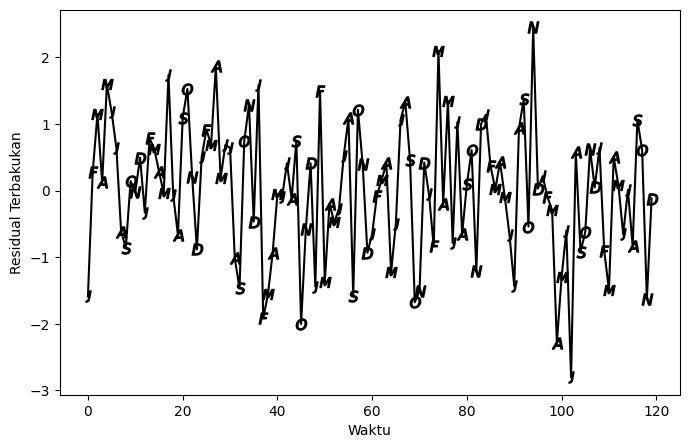

In [130]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


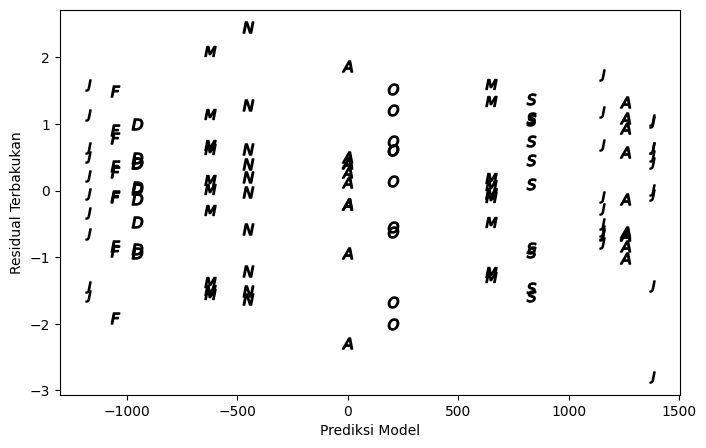

In [131]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

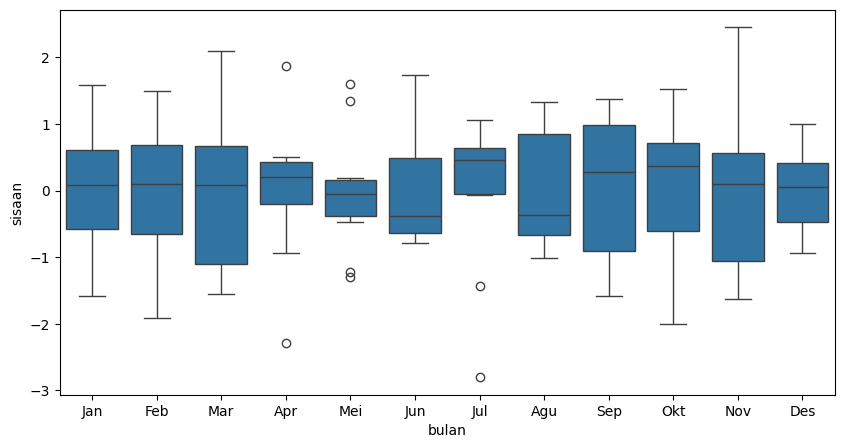

In [132]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Berdasarkan tiga plot tersebut, residual terbakukan secara umum menyebar di sekitar nilai nol dan tidak menunjukkan pola tertentu terhadap waktu maupun prediksi model. Hal ini menunjukkan bahwa tidak terdapat pola sistematis yang jelas pada residual. Pada boxplot sisaan berdasarkan bulan, penyebaran residual antarbulan terlihat cukup bervariasi dan terdapat beberapa pencilan pada beberapa bulan. Namun, secara keseluruhan residual masih berada di sekitar nol. Dengan demikian, model regresi musiman secara umum sudah cukup baik dalam menangkap pola musiman pada deret, meskipun terdapat beberapa nilai pencilan pada residual.

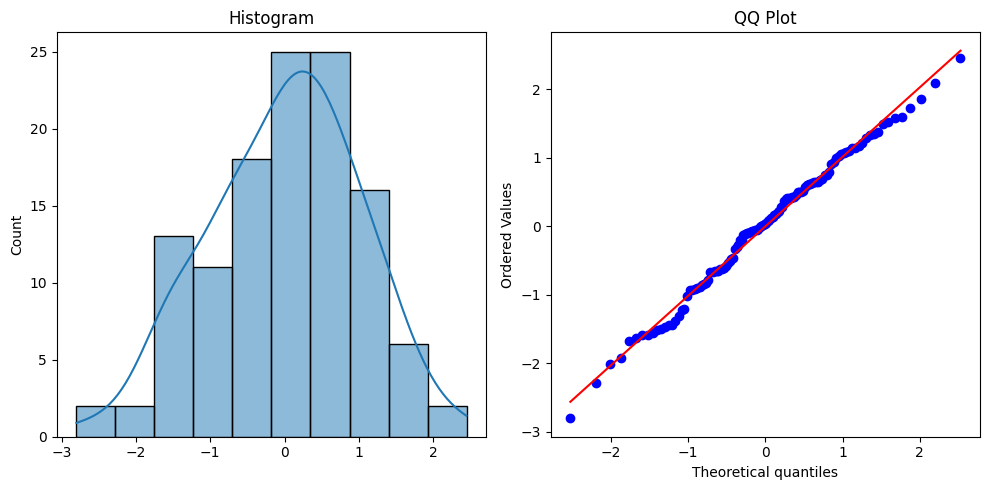

In [133]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Berdasarkan histogram dan QQ Plot, residual secara umum mengikuti pola distribusi normal. Histogram menunjukkan bentuk yang mendekati lonceng dan berpusat di sekitar nol, sedangkan pada QQ Plot sebagian besar titik berada di sekitar garis diagonal. Dengan demikian, dari sisi asumsi normalitas residual, model yang dipaskan dapat dikatakan cukup tepat. Meskipun terdapat sedikit penyimpangan pada bagian ekor, penyimpangan tersebut tidak terlalu besar.

In [137]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

from scipy.stats import shapiro

shapiro_test = shapiro(musiman.resid)

print(f"Shapiro-Wilk Test: Statistics = {shapiro_test.statistic:.4f}, p-value = {shapiro_test.pvalue:.4f}")

Shapiro-Wilk Test: Statistics = 0.9923, p-value = 0.7487


Hasil uji Shapiro-Wilk menunjukkan nilai statistik sebesar 0,9923 dengan p-value sebesar 0,7487. Karena p-value lebih besar dari 0,05, maka tidak terdapat bukti yang cukup untuk menolak asumsi normalitas. Dengan demikian, residual dapat dianggap berdistribusi normal. Hasil ini sesuai dengan histogram dan QQ Plot yang menunjukkan bahwa residual secara umum mengikuti distribusi normal.

In [141]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [142]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.332e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.75e-285
Time:                        16:44:59   Log-Likelihood:                -244.46
No. Observations:                 120   AIC:                             512.9
Df Residuals:                     108   BIC:                             546.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1174.5532      0.619  -1898.968      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

Pada model tanpa intersep, masing-masing koefisien dummy bulan langsung menunjukkan nilai rata-rata deret untuk bulan tersebut. Sedangkan pada model dengan intersep, koefisien intersep menjadi nilai dasar (baseline) untuk bulan Januari, sementara koefisien bulan lainnya menunjukkan selisih nilai bulan tersebut terhadap Januari.

Pada model dengan intersep diperoleh intersep sebesar -1174,5532. Koefisien Februari sebesar 120,5480 berarti nilai Februari sekitar 120,5480 lebih tinggi dibandingkan Januari. Begitu pula koefisien bulan lainnya menunjukkan perbedaan nilai bulan tersebut terhadap Januari. Misalnya, koefisien Juli sebesar 2549,8073 berarti nilai Juli sekitar 2549,8073 lebih tinggi dibandingkan Januari.

Kedua model memiliki R-squared sebesar 1,000, sehingga keduanya mampu menjelaskan variasi data dengan sangat baik. Perbedaannya terutama terletak pada cara interpretasi koefisien. Model dengan intersep menggunakan Januari sebagai kategori dasar, sedangkan model tanpa intersep memberikan koefisien langsung untuk masing-masing bulan.

In [143]:
# uji asumsi model dengan intersep
# Uji Breusch-Pagan
bp_test_int = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)

print(f"P-value Breusch-Pagan Test: {bp_test_int[1]:.4f}")

# Uji Shapiro-Wilk
shapiro_int = stats.shapiro(musiman_int.resid)

print(f"Shapiro-Wilk Test: Statistics = {shapiro_int.statistic:.4f}, p-value = {shapiro_int.pvalue:.4f}")

P-value Breusch-Pagan Test: 0.7990
Shapiro-Wilk Test: Statistics = 0.9923, p-value = 0.7487


Berdasarkan hasil pengujian asumsi, model dengan intersep sudah memenuhi asumsi regresi. Uji Breusch-Pagan menghasilkan p-value sebesar 0,7990 yang lebih besar dari 0,05, sehingga tidak terdapat bukti adanya heteroskedastisitas. Uji Shapiro-Wilk menghasilkan p-value sebesar 0,7487 yang lebih besar dari 0,05, sehingga residual dapat dianggap berdistribusi normal. Dengan demikian, berdasarkan kedua pengujian tersebut, model dengan intersep telah memenuhi asumsi homoskedastisitas dan normalitas residual.

## Kecenderungan Linear dan Musiman

In [145]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.55, 510 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


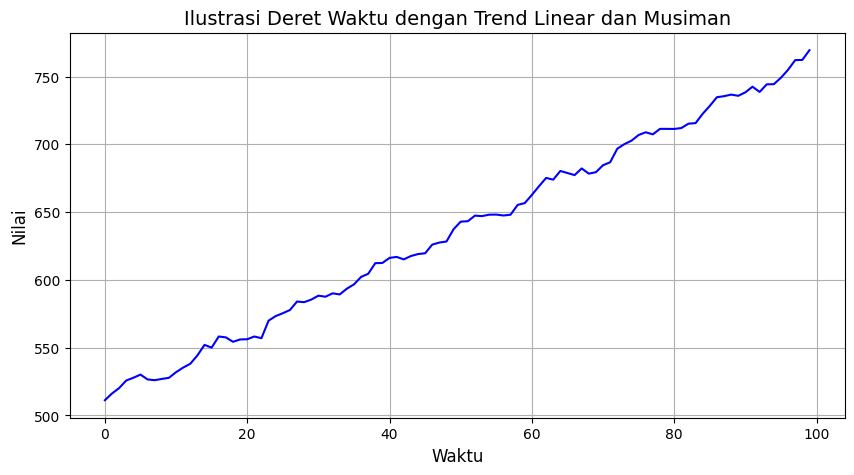

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [85]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [86]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [87]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.200e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.68e-134
Time:                        15:00:39   Log-Likelihood:                -200.88
No. Observations:                 100   AIC:                             427.8
Df Residuals:                      87   BIC:                             461.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      510.1295      0.721    707.830      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Berdasarkan hasil regresi, nilai koefisien untuk setiap bulan menunjukkan tingkat nilai deret pada bulan tersebut setelah memperhitungkan kecenderungan waktu. Koefisien period sebesar 2,5436 menunjukkan bahwa setiap kenaikan satu periode waktu, nilai deret diperkirakan meningkat sebesar 2,5436 satuan, dengan pola musiman tetap.

Koefisien bulan juga menunjukkan adanya perbedaan nilai deret antarbulan. Misalnya, koefisien Januari sebesar 510,1295, sedangkan Februari sebesar 512,8565 dan Mei sebesar 515,3789. Hal ini menunjukkan bahwa selain memiliki kecenderungan meningkat dari waktu ke waktu, deret juga memiliki pola musiman yang menyebabkan nilai berbeda pada masing-masing bulan.

Model memiliki R-squared sebesar 0,999, sehingga model mampu menjelaskan sekitar 99,9% variasi pada deret. Dengan demikian, model berhasil menangkap kedua pola, yaitu kecenderungan linear dan pola musiman.

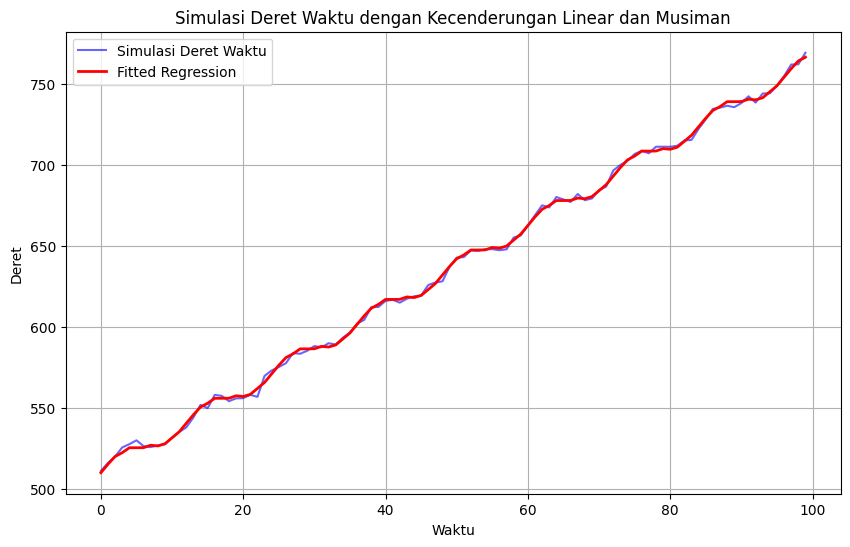

In [147]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [149]:
# uji asumsi model
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# Uji normalitas residual
shapiro_test = stats.shapiro(model_mix.resid)
print(f"Shapiro-Wilk: Statistik = {shapiro_test.statistic:.4f}, p-value = {shapiro_test.pvalue:.4f}")

# Uji heteroskedastisitas
exog_for_bp = sm.add_constant(model_mix.model.exog, prepend=True)
bp_test = het_breuschpagan(model_mix.resid, exog_for_bp)
print(f"Breusch-Pagan: p-value = {bp_test[1]:.4f}")

# Uji autokorelasi
ljung_box = acorr_ljungbox(model_mix.resid, lags=[12], return_df=True)
print(f"Ljung-Box (lag 12): p-value = {ljung_box['lb_pvalue'].iloc[0]:.4f}")

Shapiro-Wilk: Statistik = 0.9954, p-value = 0.9838
Breusch-Pagan: p-value = 0.9118
Ljung-Box (lag 12): p-value = 0.4313


Berdasarkan hasil pengecekan asumsi model, dapat disimpulkan bahwa tidak terdapat pelanggaran asumsi yang berarti. Uji Shapiro-Wilk menghasilkan p-value sebesar 0,9838 > 0,05, sehingga residual dapat dianggap berdistribusi normal. Uji Breusch-Pagan menghasilkan p-value sebesar 0,9118 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas. Uji Ljung-Box menghasilkan p-value sebesar 0,4313 > 0,05, sehingga tidak terdapat indikasi autokorelasi residual. Dengan demikian, model regresi linear dan musiman dapat dikatakan telah memenuhi asumsi-asumsi regresi yang diuji.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [151]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

KeyError: 'Value'

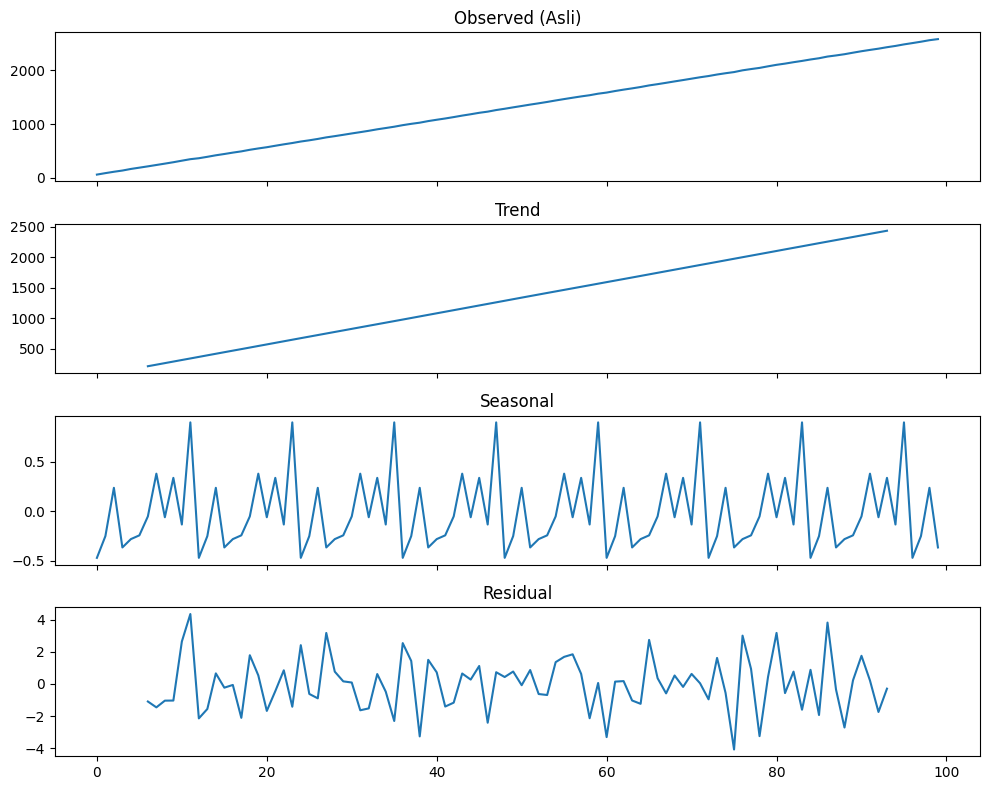

In [91]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

In [92]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

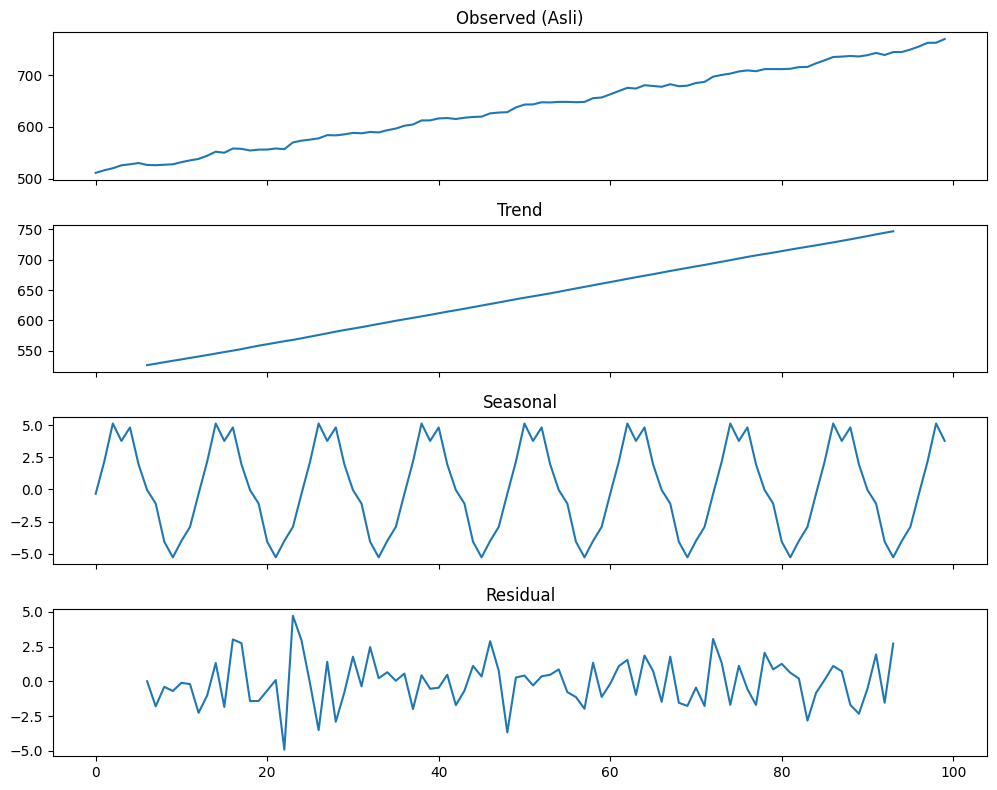

In [93]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [94]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.55, 510 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

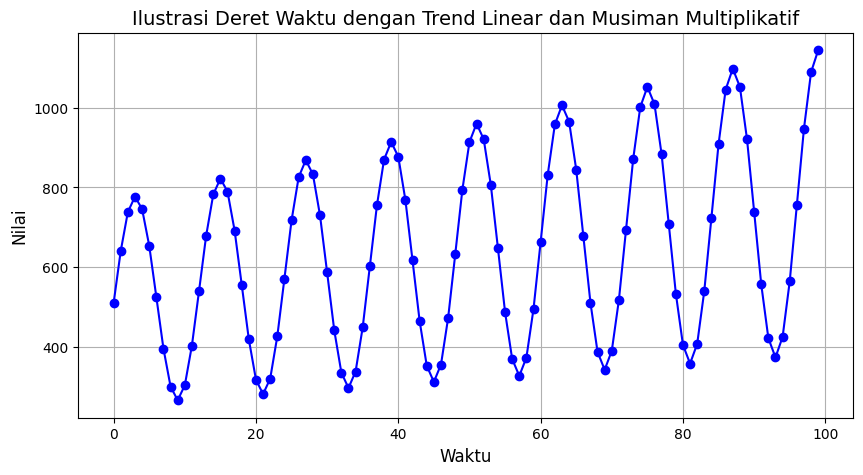

In [95]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [96]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

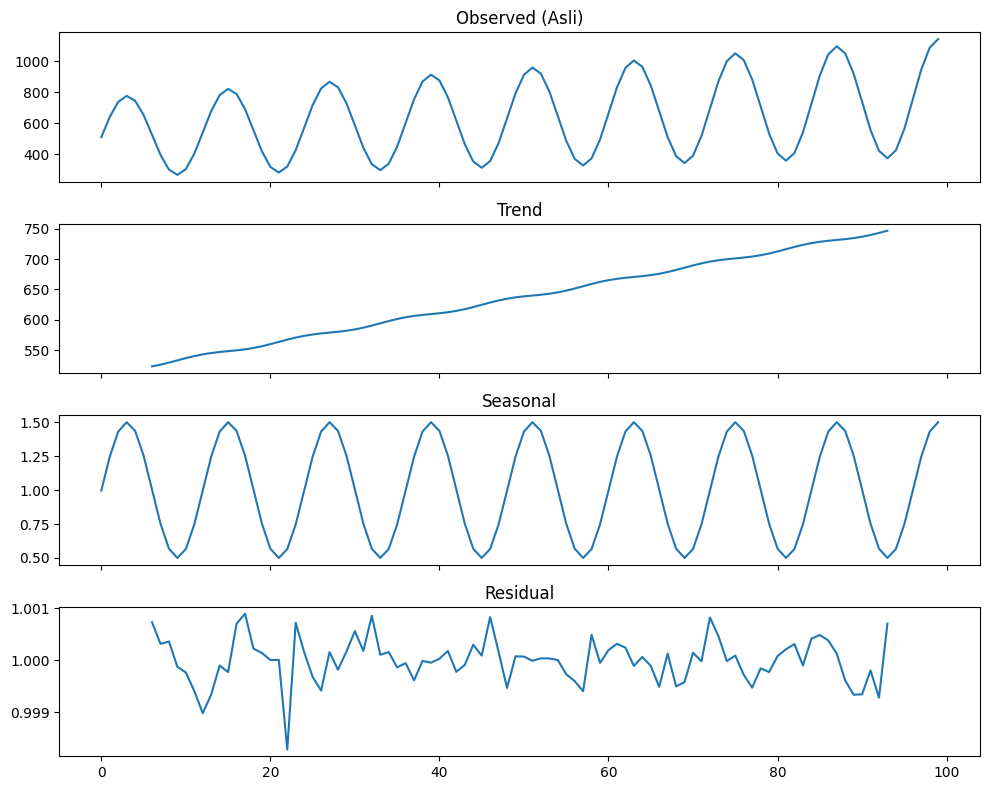

In [97]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

In [98]:
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

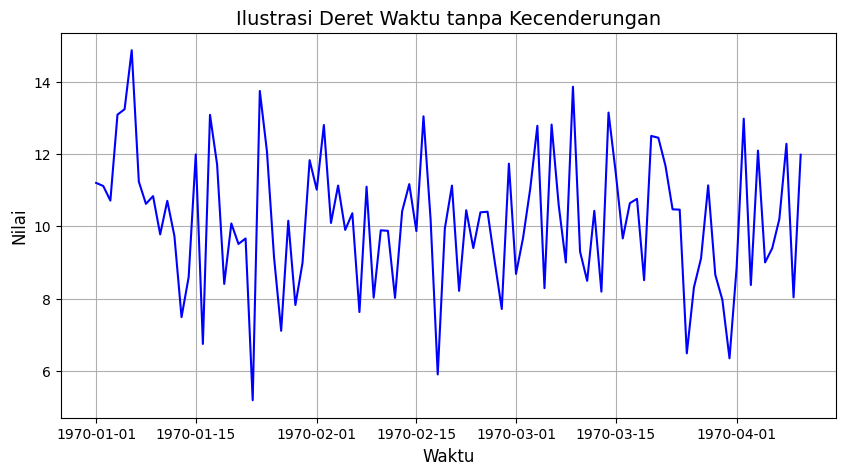

In [99]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

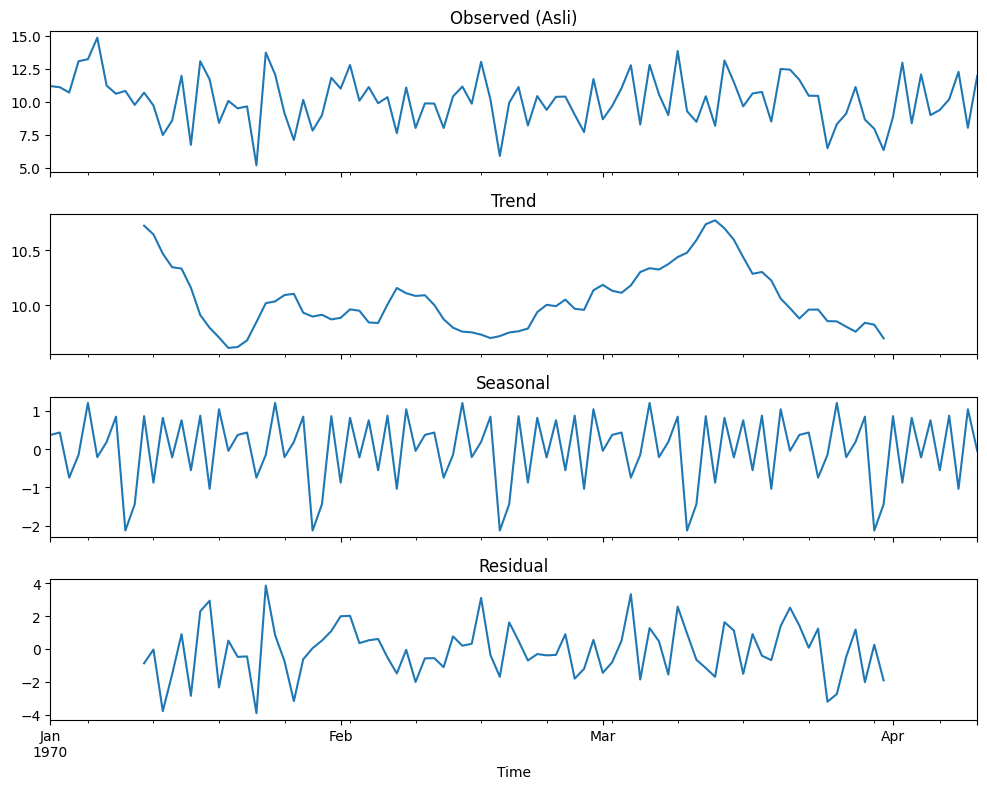

In [100]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?